In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler



In [6]:
df= pd.read_csv('knn_regression_dataset.csv')
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [8]:
df.columns

Index(['age', 'income', 'loan_amount', 'credit_score', 'city',
       'employment_type', 'target'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1000 non-null   int64  
 1   income           970 non-null    float64
 2   loan_amount      970 non-null    float64
 3   credit_score     971 non-null    float64
 4   city             1000 non-null   object 
 5   employment_type  1000 non-null   object 
 6   target           1000 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB


In [10]:
df['income'].fillna(df['income'].mean(), inplace=True)
df['loan_amount'].fillna(df['loan_amount'].mean(), inplace=True)
df['credit_score'].fillna(df['credit_score'].mean(), inplace=True)

C:\Users\Brahm\AppData\Local\Temp\ipykernel_18984\1291295795.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(df['income'].mean(), inplace=True)
C:\Users\Brahm\AppData\Local\Temp\ipykernel_18984\1291295795.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [11]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['income'] >= Q1 - 1.5*IQR) & (df['income'] <= Q3 + 1.5*IQR)]

In [12]:
df.describe()

,age,income,loan_amount,credit_score,target
count,975.000000,975.000000,975.000000,975.000000,975.000000
mean,43.860513,51149.801242,204789.703303,649.457534,124868.760964
std,14.992573,14382.951741,57574.182971,69.957846,31317.483906
min,18.000000,12508.914277,49024.392209,440.620482,40800.918241
25%,31.000000,41319.385105,169657.929804,602.682479,105637.155097
50%,44.000000,51489.984581,202544.385093,649.422223,123508.332883
75%,56.000000,60110.006326,234650.605757,693.567342,140802.442965
max,69.000000,89485.730973,597644.058452,858.968130,333440.450713


In [13]:
df.isnull().sum()

age                0
income             0
loan_amount        0
credit_score       0
city               0
employment_type    0
target             0
dtype: int64

In [14]:
df['income'].fillna(df['income'].mean(), inplace=True)
df['loan_amount'].fillna(df['loan_amount'].mean(), inplace=True)
df['credit_score'].fillna(df['credit_score'].mean(), inplace=True)


C:\Users\Brahm\AppData\Local\Temp\ipykernel_18984\4254363321.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(df['income'].mean(), inplace=True)
C:\Users\Brahm\AppData\Local\Temp\ipykernel_18984\4254363321.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [15]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) & (df[column] <= upper)]

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df = remove_outliers(df, col)

print("\nAfter Removing Outliers:")
print(df.shape)


After Removing Outliers:
(931, 7)


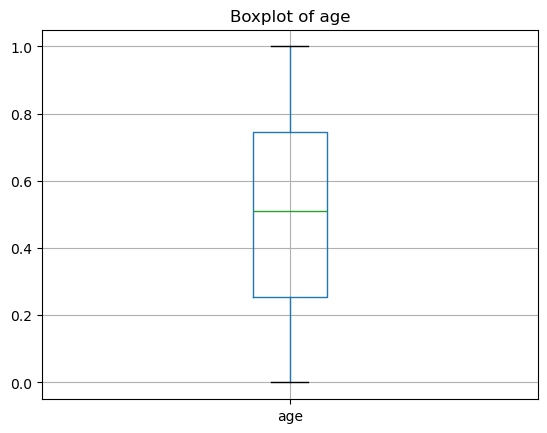

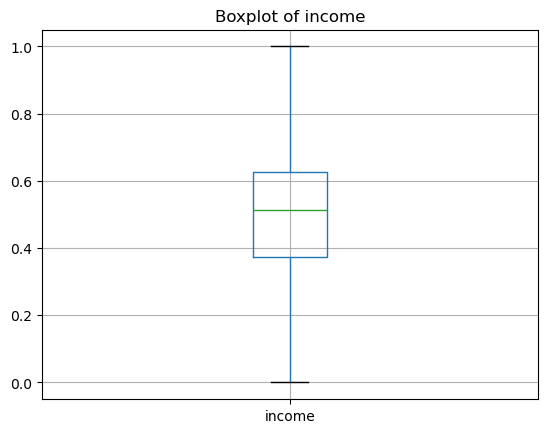

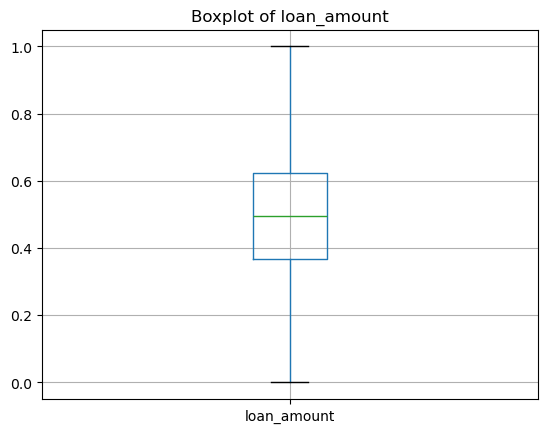

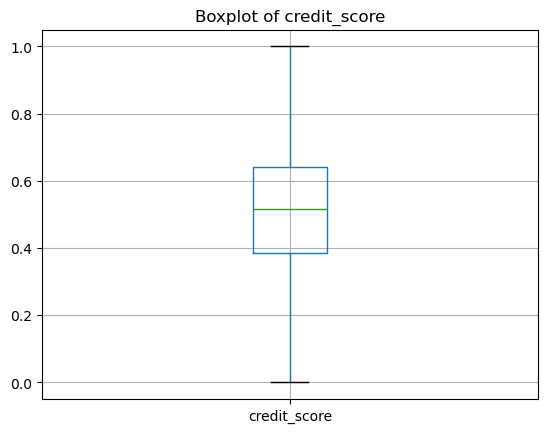

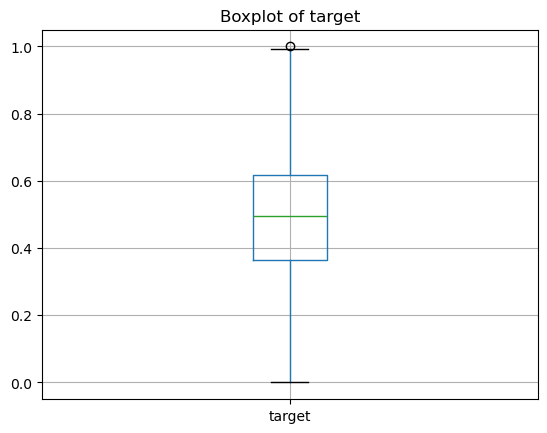

In [74]:
for col in num_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()


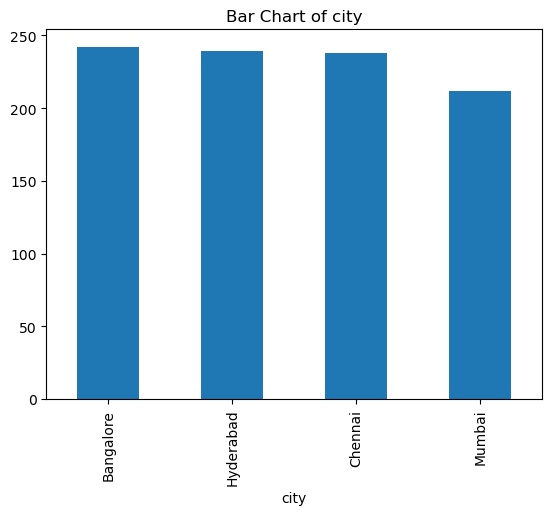

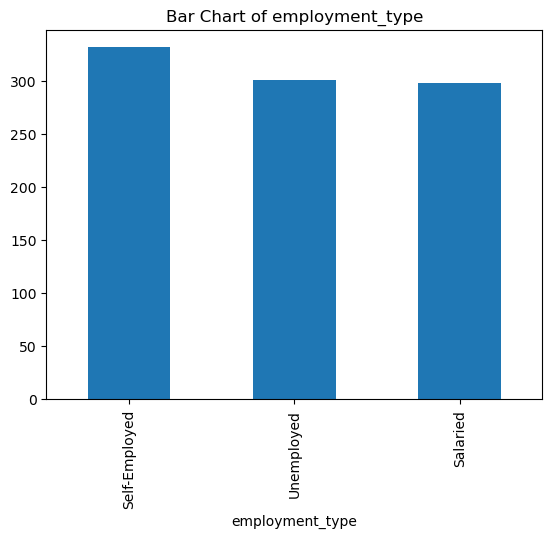

In [17]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Bar Chart of {col}")
    plt.savefig(f"bar_{col}.png")
    plt.show()


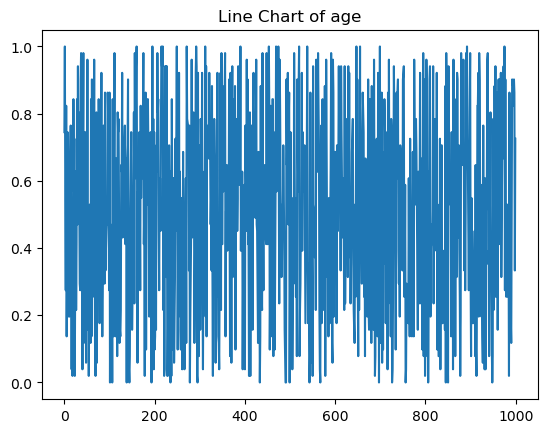

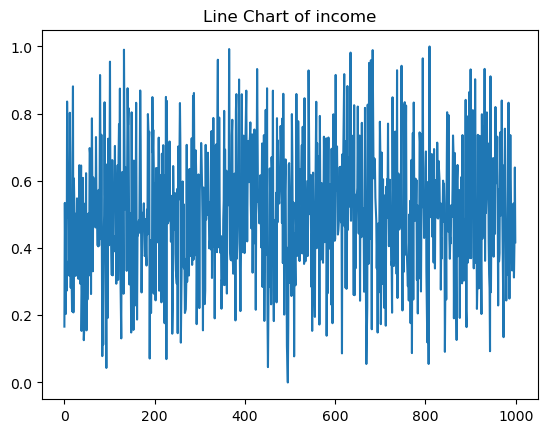

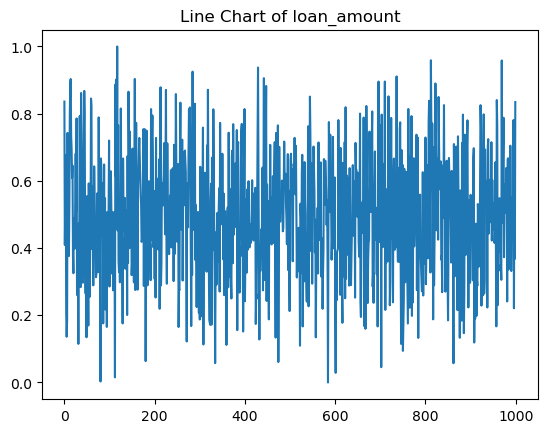

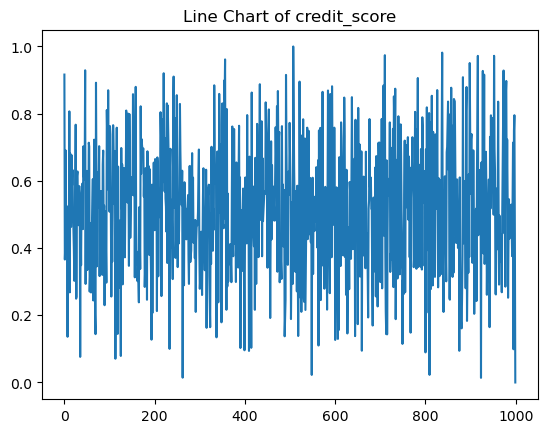

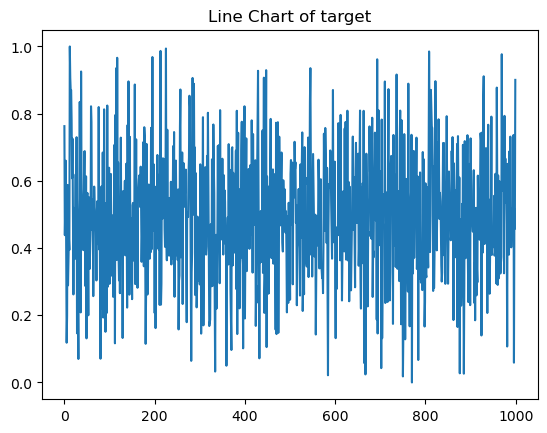

In [75]:
for col in num_cols:
    plt.figure()
    plt.plot(df[col])
    plt.title(f"Line Chart of {col}")
    plt.show()

In [19]:
df = pd.get_dummies(df, columns=cat_cols)


In [21]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [22]:
print("\nFinal Processed Dataset:")
print(df.head())



Final Processed Dataset:
        age    income  loan_amount  credit_score    target  city_Bangalore  \
0  0.807410 -1.773605     1.851436      2.089069  1.412026           False   
1  1.674883  0.142573    -0.461661     -0.788078 -0.286829           False   
2  0.140123 -0.873597     0.217411     -0.561696  0.170746           False   
3 -0.794079 -1.578598     0.987399      0.907701  0.873575           False   
4  1.074325 -0.757373    -1.569731     -0.392324 -0.482403           False   

   city_Chennai  city_Hyderabad  city_Mumbai  employment_type_Salaried  \
0          True           False        False                      True   
1          True           False        False                      True   
2          True           False        False                      True   
3          True           False        False                     False   
4         False            True        False                     False   

   employment_type_Self-Employed  employment_type_Unemployed

In [23]:
df.to_csv("processed_dataset.csv", index=False)

print("\n✅ Analysis Completed Successfully!")


✅ Analysis Completed Successfully!


In [24]:
# Select numerical columns
num_cols = ["age", "income", "loan_amount", "credit_score"]

# Remove outliers using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df)

          age    income  loan_amount  credit_score    target  city_Bangalore  \
0    0.807410 -1.773605     1.851436      2.089069  1.412026           False   
1    1.674883  0.142573    -0.461661     -0.788078 -0.286829           False   
2    0.140123 -0.873597     0.217411     -0.561696  0.170746           False   
3   -0.794079 -1.578598     0.987399      0.907701  0.873575           False   
4    1.074325 -0.757373    -1.569731     -0.392324 -0.482403           False   
..        ...       ...          ...           ...       ...             ...   
995  1.074325  0.133603     1.553730     -2.184320  1.274077           False   
996  1.341240 -1.012438    -1.482976      1.214274 -2.273646            True   
997  1.207782 -0.535980     0.726708      1.456985  0.122586           False   
998 -0.593893  0.691959    -0.685971     -0.303742 -0.188286            True   
999  0.740681 -0.467561     1.843185     -2.703081  2.132857           False   

     city_Chennai  city_Hyderabad  city

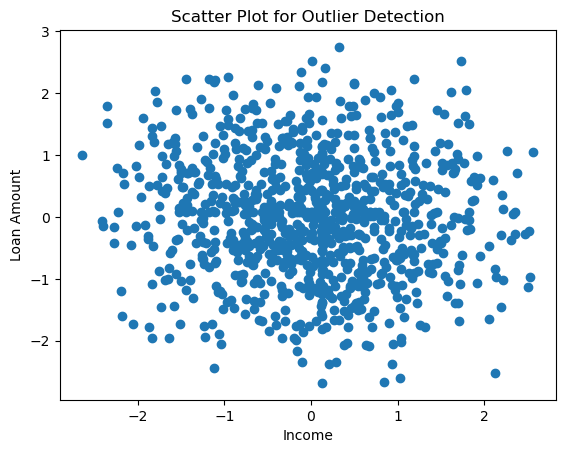

In [25]:
# Scatter plot: Income vs Loan Amount
plt.scatter(df["income"], df["loan_amount"])

plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.title("Scatter Plot for Outlier Detection")

plt.show()

In [26]:
df["income"].fillna(df["income"].mean(), inplace=True)
df["loan_amount"].fillna(df["loan_amount"].median(), inplace=True)
df["credit_score"].fillna(df["credit_score"].mean(), inplace=True)

C:\Users\Brahm\AppData\Local\Temp\ipykernel_18984\3752858990.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["income"].fillna(df["income"].mean(), inplace=True)
C:\Users\Brahm\AppData\Local\Temp\ipykernel_18984\3752858990.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [28]:
df["income"] = df["income"].fillna(df["income"].median())
df["loan_amount"] = df["loan_amount"].fillna(df["loan_amount"].median())
df["credit_score"] = df["credit_score"].fillna(df["credit_score"].median())

In [29]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nColumn: {col}")
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)


Column: age
Lower Bound: -3.3631336512088614
Upper Bound: 3.3097363563044855

Column: income
Lower Bound: -2.6552366891113257
Upper Bound: 2.5886007110807485

Column: loan_amount
Lower Bound: -2.7661991595606517
Upper Bound: 2.7696619358097276

Column: credit_score
Lower Bound: -2.7010969502034463
Upper Bound: 2.65247368265551

Column: target
Lower Bound: -2.678865897444407
Upper Bound: 2.653437839249972


In [30]:
outliers = df[(df['income'] < lower_bound) | (df['income'] > upper_bound)]
print(outliers)

Empty DataFrame
Columns: [age, income, loan_amount, credit_score, target, city_Bangalore, city_Chennai, city_Hyderabad, city_Mumbai, employment_type_Salaried, employment_type_Self-Employed, employment_type_Unemployed]
Index: []


In [31]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower, lower, df[column])
    df[column] = np.where(df[column] > upper, upper, df[column])

In [32]:
#cap the outliers
for col in num_cols:
    cap_outliers(df, col)

In [33]:
#use clip method to remove outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower_bound, upper_bound)

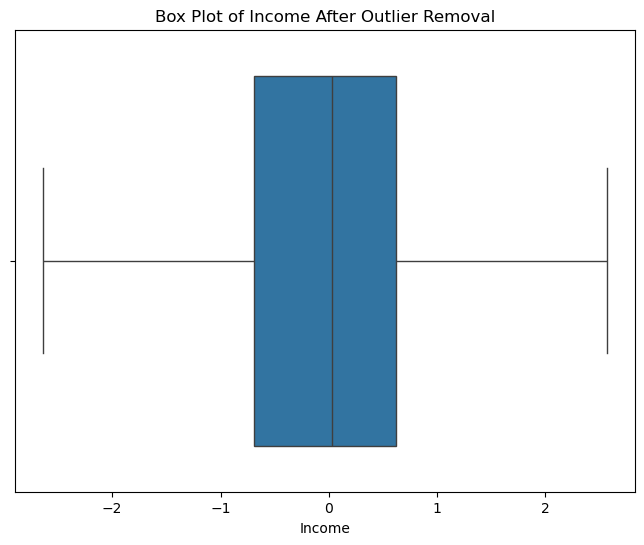

In [34]:
#Create a box plot to visualize the distribution of the 'income' column after outlier removal
plt.figure(figsize=(8, 6))      
sns.boxplot(x=df["income"])
plt.title("Box Plot of Income After Outlier Removal")
plt.xlabel("Income")
plt.show()

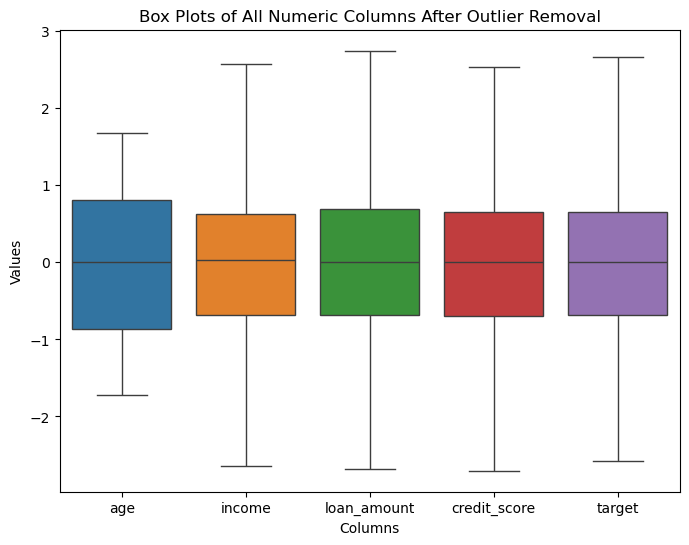

In [39]:
#Create a box plot to visualize the distribution of the all columns after outlier removal
plt.figure(figsize=(8, 6))      
sns.boxplot(data=df[num_cols])
plt.title("Box Plots of All Numeric Columns After Outlier Removal")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()

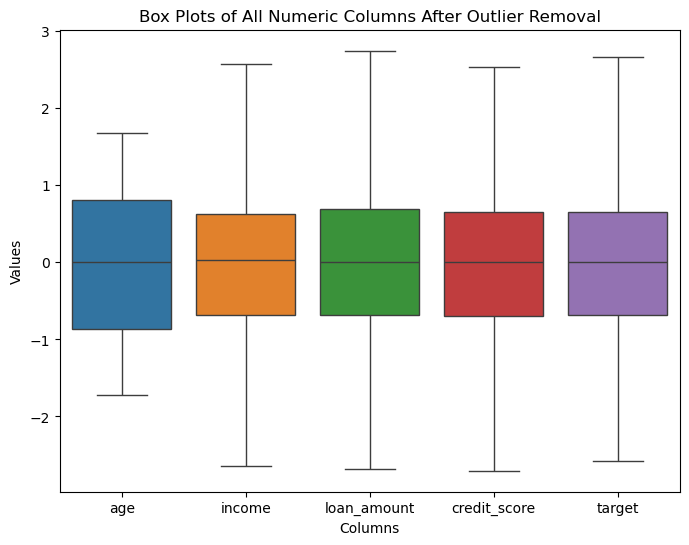

In [37]:
#Create a box plot to visualize the distribution of the all columns after outlier removal
plt.figure(figsize=(8, 6))      
sns.boxplot(data=df[num_cols])
plt.title("Box Plots of All Numeric Columns After Outlier Removal")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()

In [48]:
# Continue ML steps
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

In [47]:
print(df.columns)

Index(['age', 'income', 'loan_amount', 'credit_score', 'target',
       'city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai',
       'employment_type_Salaried', 'employment_type_Self-Employed',
       'employment_type_Unemployed'],
      dtype='object')


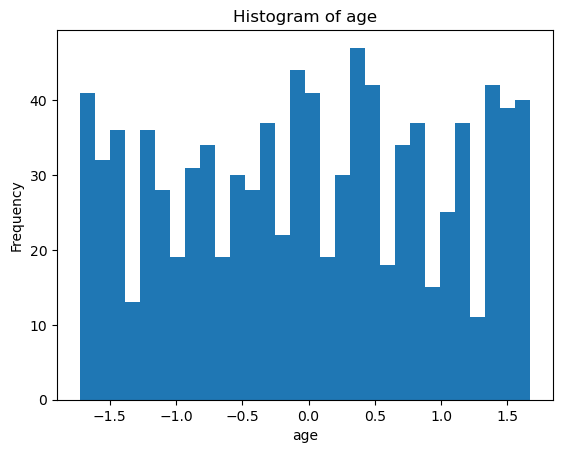

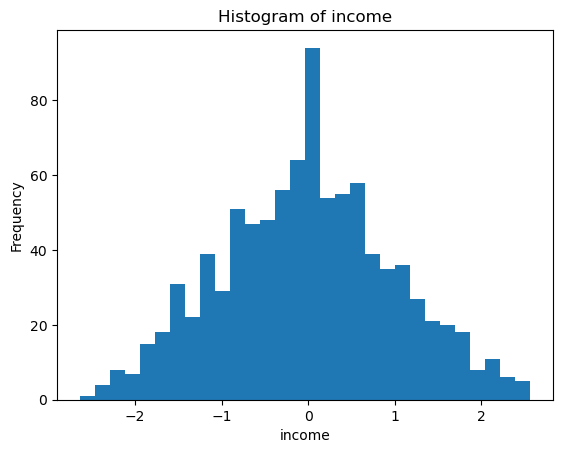

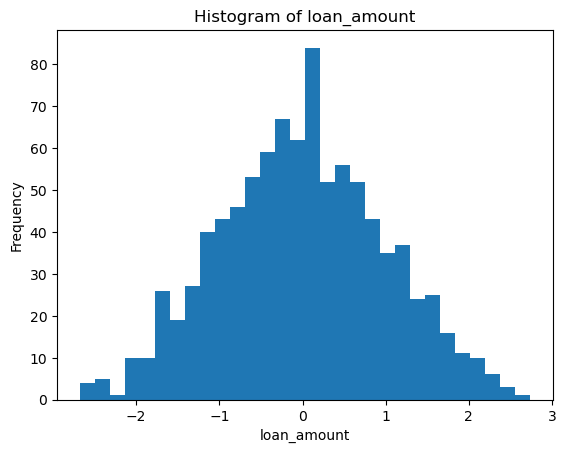

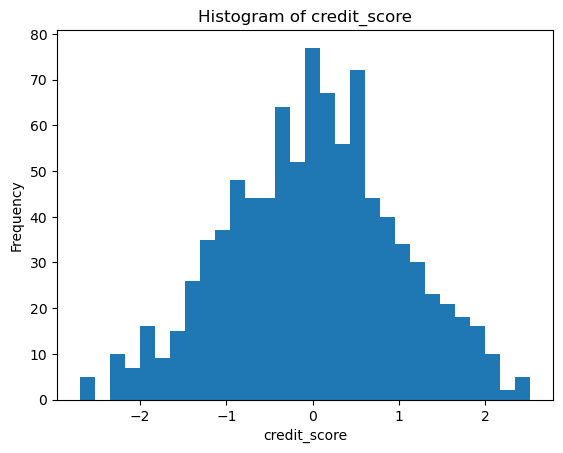

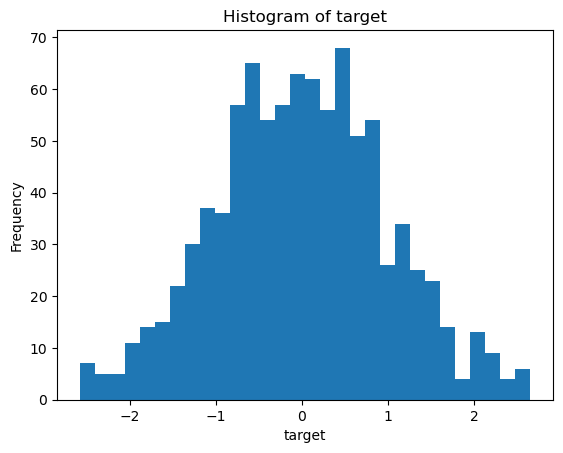

In [54]:
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [55]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

skew_values = df[num_cols].skew()

print(skew_values)

age            -0.050235
income          0.047424
loan_amount     0.021321
credit_score   -0.052380
target          0.049716
dtype: float64


In [56]:
for col in num_cols:
    skew = df[col].skew()
    
    if -0.5 <= skew <= 0.5:
        print(f"{col} ➝ Normal Distribution (Skew={skew:.2f})")
    elif skew > 0.5:
        print(f"{col} ➝ Positively Skewed (Right Skewed) (Skew={skew:.2f})")
    else:
        print(f"{col} ➝ Negatively Skewed (Left Skewed) (Skew={skew:.2f})")

age ➝ Normal Distribution (Skew=-0.05)
income ➝ Normal Distribution (Skew=0.05)
loan_amount ➝ Normal Distribution (Skew=0.02)
credit_score ➝ Normal Distribution (Skew=-0.05)
target ➝ Normal Distribution (Skew=0.05)


In [59]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns
skewness = df[num_cols].skew()

In [60]:
# Better condition for normal (instead of == 0)
normal_skewed_features = skewness[(skewness >= -0.5) & (skewness <= 0.5)].index.tolist()

positive_skewed_features = skewness[skewness > 0.5].index.tolist()

negative_skewed_features = skewness[skewness < -0.5].index.tolist()

print("Normal skewed features: ", normal_skewed_features)
print("Positive skewed features: ", positive_skewed_features)
print("Negative skewed features: ", negative_skewed_features)

Normal skewed features:  ['age', 'income', 'loan_amount', 'credit_score', 'target']
Positive skewed features:  []
Negative skewed features:  []


In [62]:
print(skewness)

age            -0.050235
income          0.047424
loan_amount     0.021321
credit_score   -0.052380
target          0.049716
dtype: float64


In [67]:
normal_skew=['income','lean_amount']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,0.745098,0.166250,0.836030,0.916384,0.762905,False,True,False,False,True,False,False
1,1.000000,0.534352,0.409243,0.365971,0.438443,False,True,False,False,True,False,False
2,0.549020,0.339144,0.534538,0.409279,0.525835,False,True,False,False,True,False,False
3,0.274510,0.203712,0.676608,0.690382,0.660067,False,True,False,False,False,False,True
4,0.823529,0.361470,0.204794,0.441680,0.401091,False,False,True,False,False,False,True


In [66]:
# check the normal , postive skewness and negative skewness features
normal_skewed_features = skewness[skewness == 0].index.tolist()
positive_skewed_features = skewness[skewness > 0].index.tolist()
negative_skewed_features = skewness[skewness < 0].index.tolist()
 
print("Normal skewed features: ", normal_skewed_features)
print("Positive skewed features: ", positive_skewed_features)
print("Negative skewed features: ", negative_skewed_features)

Normal skewed features:  []
Positive skewed features:  ['income', 'loan_amount', 'target']
Negative skewed features:  ['age', 'credit_score']


In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["credit_score"] = scaler.fit_transform(df[["credit_score"]])
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,0.745098,0.166250,0.836030,2.095664,0.762905,False,True,False,False,True,False,False
1,1.000000,0.534352,0.409243,-0.796868,0.438443,False,True,False,False,True,False,False
2,0.549020,0.339144,0.534538,-0.569275,0.525835,False,True,False,False,True,False,False
3,0.274510,0.203712,0.676608,0.907979,0.660067,False,True,False,False,False,False,True
4,0.823529,0.361470,0.204794,-0.398998,0.401091,False,False,True,False,False,False,True


In [69]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = ['age','income','loan_amount','credit_score','target']

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,0.745098,0.166250,0.836030,0.916384,0.762905,False,True,False,False,True,False,False
1,1.000000,0.534352,0.409243,0.365971,0.438443,False,True,False,False,True,False,False
2,0.549020,0.339144,0.534538,0.409279,0.525835,False,True,False,False,True,False,False
3,0.274510,0.203712,0.676608,0.690382,0.660067,False,True,False,False,False,False,True
4,0.823529,0.361470,0.204794,0.441680,0.401091,False,False,True,False,False,False,True


In [70]:
# convert True/False to 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# check result
print(df.head())

        age    income  loan_amount  credit_score    target  city_Bangalore  \
0  0.745098  0.166250     0.836030      0.916384  0.762905               0   
1  1.000000  0.534352     0.409243      0.365971  0.438443               0   
2  0.549020  0.339144     0.534538      0.409279  0.525835               0   
3  0.274510  0.203712     0.676608      0.690382  0.660067               0   
4  0.823529  0.361470     0.204794      0.441680  0.401091               0   

   city_Chennai  city_Hyderabad  city_Mumbai  employment_type_Salaried  \
0             1               0            0                         1   
1             1               0            0                         1   
2             1               0            0                         1   
3             1               0            0                         0   
4             0               1            0                         0   

   employment_type_Self-Employed  employment_type_Unemployed  
0                      

In [71]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

scaler = MinMaxScaler()

num_cols = ['age','income','loan_amount','credit_score','target']
df[num_cols] = scaler.fit_transform(df[num_cols])

# Split features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train KNN Regression model
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

print(df.head())

Mean Squared Error: 0.012364115051863005
        age    income  loan_amount  credit_score    target  city_Bangalore  \
0  0.745098  0.166250     0.836030      0.916384  0.762905               0   
1  1.000000  0.534352     0.409243      0.365971  0.438443               0   
2  0.549020  0.339144     0.534538      0.409279  0.525835               0   
3  0.274510  0.203712     0.676608      0.690382  0.660067               0   
4  0.823529  0.361470     0.204794      0.441680  0.401091               0   

   city_Chennai  city_Hyderabad  city_Mumbai  employment_type_Salaried  \
0             1               0            0                         1   
1             1               0            0                         1   
2             1               0            0                         1   
3             1               0            0                         0   
4             0               1            0                         0   

   employment_type_Self-Employed  employment_

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Split data
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# ==========================
# Evaluation Metrics
# ==========================

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score (Accuracy-like):", r2)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

R2 Score (Accuracy-like): 0.582872146724811
Mean Absolute Error: 0.0882920451144885
Mean Squared Error: 0.012364115051863005


In [73]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

# Scaling
scaler = MinMaxScaler()
num_cols = ['age','income','loan_amount','credit_score','target']
df[num_cols] = scaler.fit_transform(df[num_cols])

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Find best K
best_k = 1
best_score = 0

for k in range(1,21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    
    if score > best_score:
        best_score = score
        best_k = k

print("Best K:", best_k)
print("Best R2 Score:", best_score)

Best K: 3
Best R2 Score: 0.5910462200868212


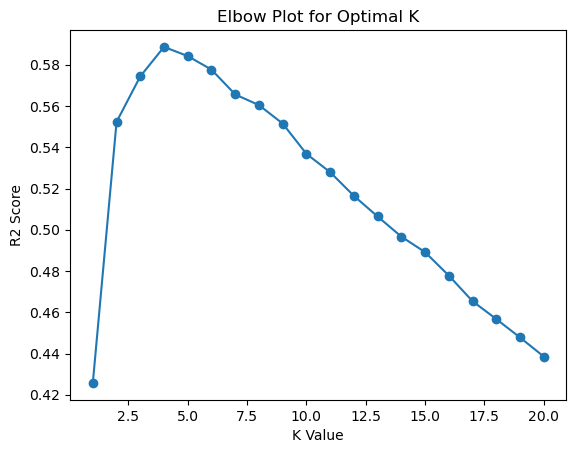

In [78]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy (simplifies indexing)
X_np = np.array(X)
y_np = np.array(y)

loo = LeaveOneOut()

k_values = list(range(1, 21))
r2_scores = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    y_true, y_pred = [], []
    
    for train_index, test_index in loo.split(X_np):
        X_train, X_test = X_np[train_index], X_np[test_index]
        y_train, y_test = y_np[train_index], y_np[test_index]
        
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        
        y_true.append(y_test[0])
        y_pred.append(pred[0])
    
    score = r2_score(y_true, y_pred)
    r2_scores.append(score)

# Plot Elbow Graph
plt.figure()
plt.plot(k_values, r2_scores, marker='o')
plt.title("Elbow Plot for Optimal K")
plt.xlabel("K Value")
plt.ylabel("R2 Score")
plt.show()

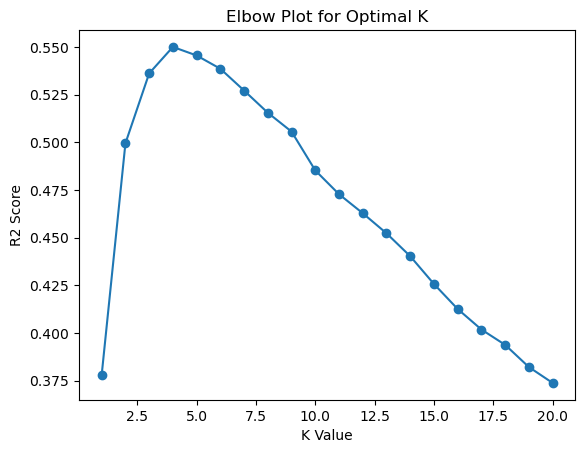

In [79]:
from sklearn.model_selection import cross_val_score

k_values = list(range(1, 21))
r2_scores = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    r2_scores.append(scores.mean())

# Plot
plt.figure()
plt.plot(k_values, r2_scores, marker='o')
plt.title("Elbow Plot for Optimal K")
plt.xlabel("K Value")
plt.ylabel("R2 Score")
plt.show()

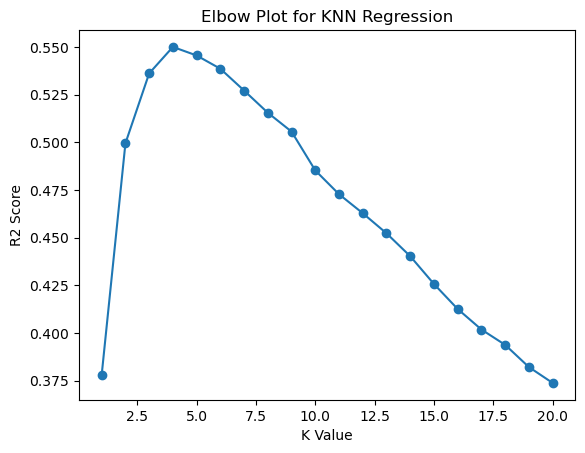

In [81]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

k_values = list(range(1, 21))
r2_scores = []

# Loop through K values
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    
    # 5-Fold Cross Validation
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    # Take average score
    r2_scores.append(scores.mean())

# Plot Elbow Graph
plt.figure()
plt.plot(k_values, r2_scores, marker='o')
plt.title("Elbow Plot for KNN Regression")
plt.xlabel("K Value")
plt.ylabel("R2 Score")
plt.show()

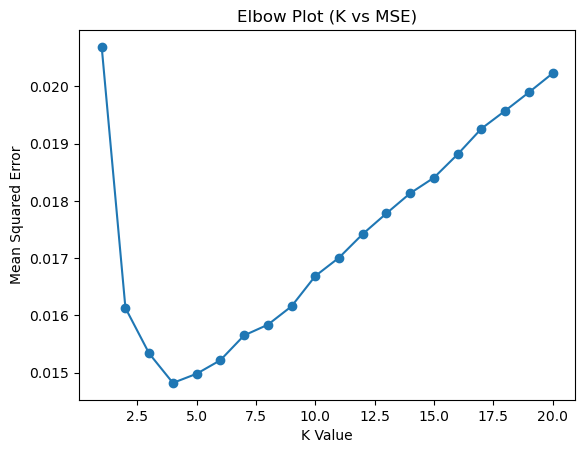

In [82]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays (IMPORTANT)
X_np = np.array(X)
y_np = np.array(y)

# Define Leave-One-Out
loo = LeaveOneOut()

k_values = list(range(1, 21))
mse_scores = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    y_true, y_pred = [], []
    
    for train_index, test_index in loo.split(X_np):
        X_train, X_test = X_np[train_index], X_np[test_index]
        y_train, y_test = y_np[train_index], y_np[test_index]
        
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        
        y_true.append(y_test[0])
        y_pred.append(pred[0])
    
    mse = mean_squared_error(y_true, y_pred)
    mse_scores.append(mse)

# Plot Elbow Graph (MSE)
plt.figure()
plt.plot(k_values, mse_scores, marker='o')
plt.title("Elbow Plot (K vs MSE)")
plt.xlabel("K Value")
plt.ylabel("Mean Squared Error")
plt.show()

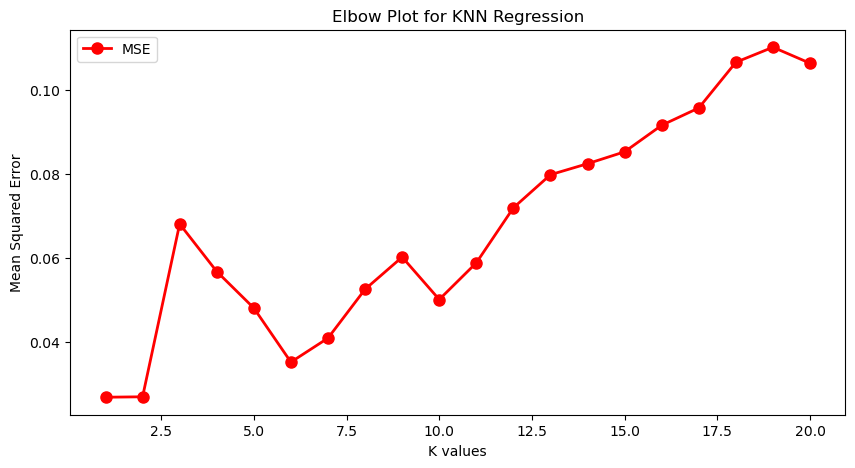

In [83]:
# make the elbow plot to find the optimal value of k
mse_values = []
k_values = range(1, 21)
 
for k in k_values:
    # load the model
    knn_regressor = KNeighborsRegressor(n_neighbors=k)
 
    # fit the model on the training data
    knn_regressor.fit(X_train, y_train)
 
    #predict the target variable on the testing data
    y_pred = knn_regressor.predict(X_test)
 
    #find the MSE
    mse = mean_squared_error(y_test, y_pred)
 
    #append the MSE value to the list
    mse_values.append(mse)
 
# plot the elbow plot
plt.figure(figsize=(10,5))
plt.plot(k_values, mse_values, marker='o',color='red',linewidth=2,markersize=8,label='MSE',)
plt.title("Elbow Plot for KNN Regression")
plt.xlabel("K values")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()
 

In [84]:
best_k = k_values[mse_scores.index(min(mse_scores))]
print("Best K:", best_k)
print("Minimum MSE:", min(mse_scores))

Best K: 4
Minimum MSE: 0.014820226372739784


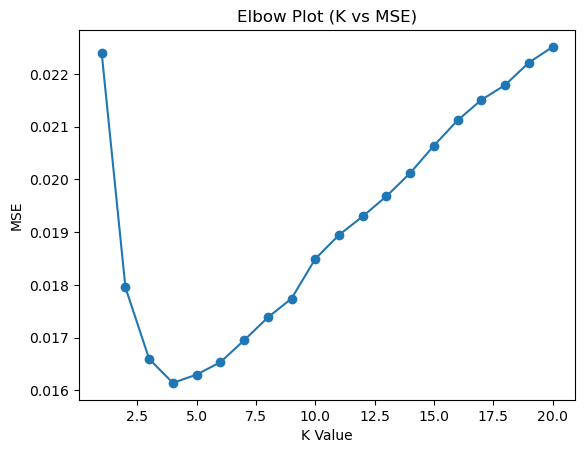

In [85]:
from sklearn.model_selection import cross_val_score

mse_scores = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    mse_scores.append(-scores.mean())

plt.figure()
plt.plot(k_values, mse_scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("MSE")
plt.title("Elbow Plot (K vs MSE)")
plt.show()

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# =========================
# 1. Split Data
# =========================
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 2. Scaling (ONLY for KNN)
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 3. KNN MODEL
# =========================
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_knn = knn.predict(X_train_scaled)
y_test_pred_knn = knn.predict(X_test_scaled)

# Accuracy (R2 Score)
knn_train_acc = r2_score(y_train, y_train_pred_knn)
knn_test_acc = r2_score(y_test, y_test_pred_knn)

print("KNN Train Accuracy:", knn_train_acc)
print("KNN Test Accuracy:", knn_test_acc)

# =========================
# 4. DECISION TREE MODEL
# =========================
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

# Predictions
y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

# Accuracy (R2 Score)
dt_train_acc = r2_score(y_train, y_train_pred_dt)
dt_test_acc = r2_score(y_test, y_test_pred_dt)

print("\nDecision Tree Train Accuracy:", dt_train_acc)
print("Decision Tree Test Accuracy:", dt_test_acc)

KNN Train Accuracy: 0.7442623815869007
KNN Test Accuracy: 0.6248254160845825

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.5825794306635343
